# UMAP — An Illustrated Tour

> **Uniform Manifold Approximation and Projection** builds a fuzzy graph of nearest neighbours in high-D and lays it out in low-D so the same edges are preserved. Faster than t-SNE and arguably keeps a bit more global structure.

---

**What we cover:**
- The recipe — fuzzy simplicial graph + force-directed layout
- Two key knobs: `n_neighbors` (local vs global) and `min_dist` (clumpiness)
- 2 × 2 sweep on the digits dataset
- UMAP vs t-SNE side by side
- When to reach for UMAP

## The picture — k-NN graph + low-dim layout that preserves topology

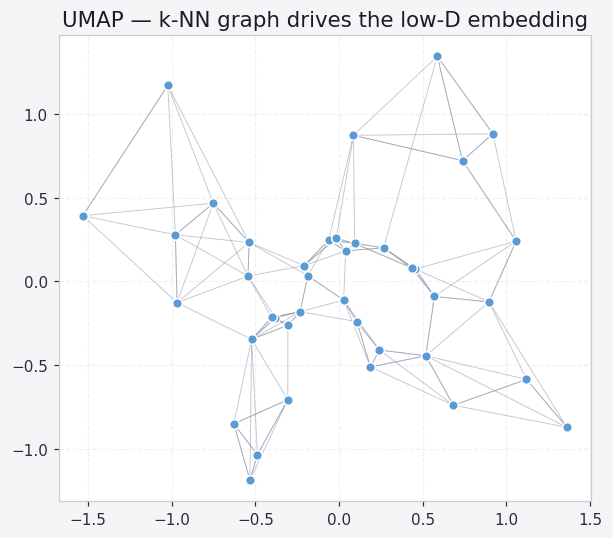

In [1]:
# (schematic — drawn from smooth curves, not measured)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, FancyBboxPatch, Ellipse, Rectangle, Circle, FancyArrowPatch
plt.rcParams.update({
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'legend.facecolor':'#ffffff','legend.edgecolor':'#c8ccd4','figure.dpi':110,
})
P = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']
rng = np.random.RandomState(0)
fig, ax = plt.subplots(figsize=(7, 5))
pts = rng.randn(40, 2)*0.6
from scipy.spatial.distance import cdist
D = cdist(pts, pts); k = 4
for i in range(len(pts)):
    nn = np.argsort(D[i])[1:k+1]
    for j in nn:
        ax.plot([pts[i,0], pts[j,0]], [pts[i,1], pts[j,1]], color='#888fa5', lw=0.6, alpha=0.5)
ax.scatter(pts[:,0], pts[:,1], s=40, color=P[0], edgecolor='white', zorder=4)
ax.set_aspect('equal'); ax.set_title('UMAP — k-NN graph drives the low-D embedding')
ax.grid(True); plt.tight_layout(); plt.show()


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import umap
from sklearn.manifold import TSNE
from sklearn.datasets import load_digits

PLT_STYLE = {
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':17,'axes.labelsize':13,
    'xtick.labelsize':11,'ytick.labelsize':11,'legend.fontsize':10,'legend.facecolor':'#ffffff',
    'legend.edgecolor':'#c8ccd4','figure.dpi':120,
}
plt.rcParams.update(PLT_STYLE)
cmap = plt.get_cmap('tab10')

digits = load_digits()
X, y = digits.data, digits.target
print('Digits:', X.shape)

I0000 00:00:1780225432.412102  351777 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780225432.810612  351777 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1780225435.014142  351777 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Digits: (1797, 64)


---
## The Recipe

1. **Build a weighted $k$-NN graph in high-D.** For each point, edges to its `n_neighbors` nearest points get probabilities decaying with distance, normalised so the **nearest** neighbour has weight ~1.
2. **Symmetrise** the graph (probabilistic OR).
3. **Initialise** a low-D embedding (spectral or random).
4. **Force-directed optimisation:** attractive forces along graph edges, repulsive forces between non-neighbours, until a stable layout emerges.

Mathematically, UMAP minimises a binary cross-entropy between high-D edge probabilities $\mu_{ij}$ and low-D edge probabilities $\nu_{ij}$:

$$\mathcal{L}_{\text{UMAP}} = \sum_{i \neq j} \bigl[\mu_{ij} \log \tfrac{\mu_{ij}}{\nu_{ij}} + (1 - \mu_{ij}) \log \tfrac{1-\mu_{ij}}{1-\nu_{ij}}\bigr], \qquad \nu_{ij} = \bigl(1 + a\,\|y_i - y_j\|^{2b}\bigr)^{-1}.$$

Constants $(a, b)$ are fitted from `min_dist`.

---
## Knob 1 — `n_neighbors`: Local vs Global

How many neighbours each point trusts in the high-D graph.
**Small** ($\sim$5) preserves microstructure but tears global geometry.
**Large** ($\sim$50–100) preserves global structure but smears small clusters.

## Knob 2 — `min_dist`: Clumpiness

Minimum allowed gap between points in the low-D embedding.
**Small** (0.0–0.1) packs clusters tight (good for clustering downstream).
**Large** (0.5–0.99) spreads points evenly (good for general visualisation).

/home/sandeep/workspace/learn-ml/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/home/sandeep/workspace/learn-ml/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/home/sandeep/workspace/learn-ml/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/home/sandeep/workspace/learn-ml/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/home/sandeep/workspace/learn-ml/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/home/sandeep/workspace/learn-ml/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


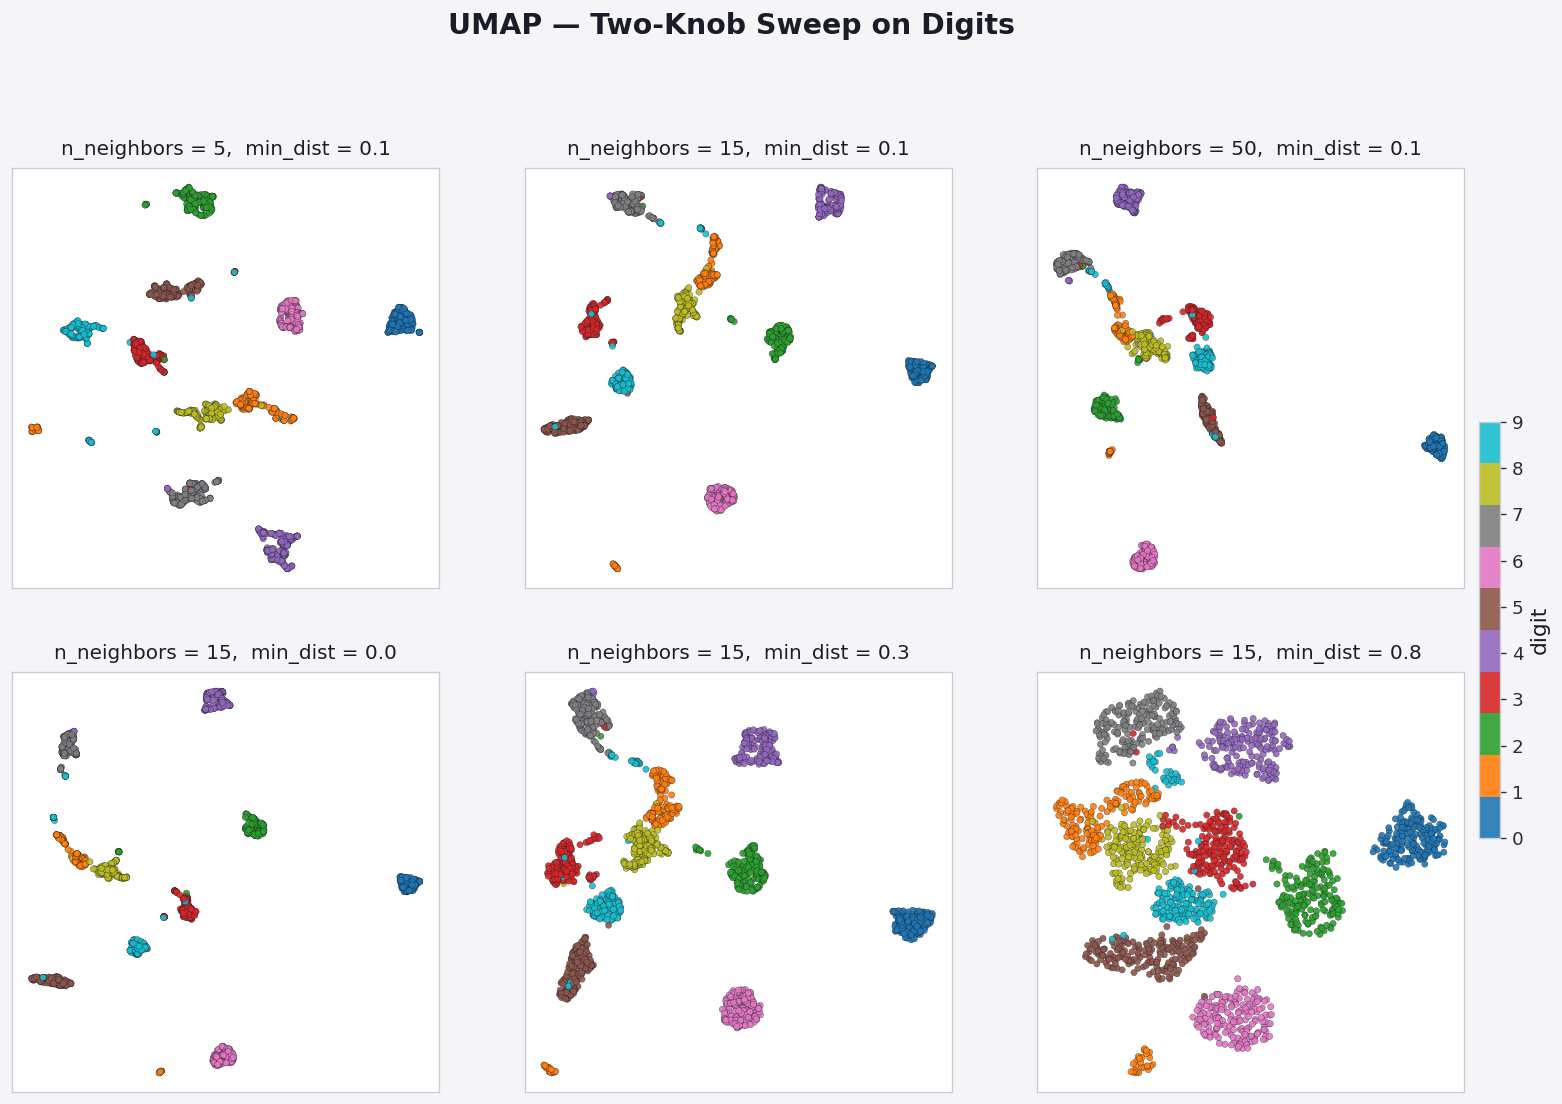

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
configs = [(5, 0.1), (15, 0.1), (50, 0.1),
           (15, 0.0), (15, 0.3), (15, 0.8)]
for ax, (nn, md) in zip(axes.flat, configs):
    Z = umap.UMAP(n_neighbors=nn, min_dist=md, n_components=2,
                  random_state=0).fit_transform(X)
    sc = ax.scatter(Z[:,0], Z[:,1], c=y, cmap=cmap, s=14, edgecolors='#1a1d27', lw=0.2, alpha=0.9)
    ax.set_title(f'n_neighbors = {nn},  min_dist = {md}', pad=8, fontsize=12)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle('UMAP — Two-Knob Sweep on Digits', fontsize=17, fontweight='bold', y=1.01)
fig.colorbar(sc, ax=axes, fraction=0.014, pad=0.01, label='digit')
plt.show()

---
## UMAP vs t-SNE — Same Data, Same Seed

Both make pretty cluster maps. UMAP tends to keep **inter-cluster** distances slightly more meaningful and runs noticeably faster on big data.

/home/sandeep/workspace/learn-ml/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


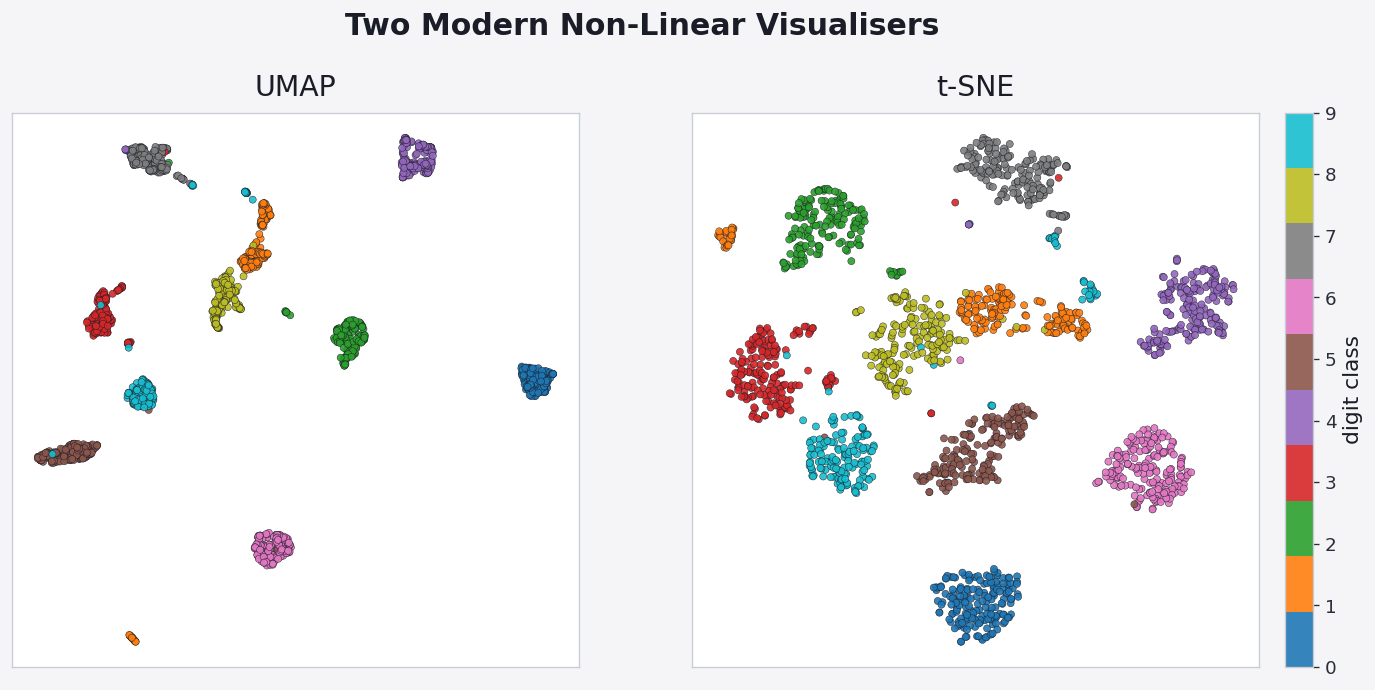

In [4]:
Z_umap = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=0).fit_transform(X)
Z_tsne = TSNE(n_components=2, perplexity=30, init='pca',
              learning_rate='auto', random_state=0, max_iter=750).fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, Z, title in zip(axes, [Z_umap, Z_tsne], ['UMAP', 't-SNE']):
    sc = ax.scatter(Z[:,0], Z[:,1], c=y, cmap=cmap, s=18, edgecolors='#1a1d27', lw=0.3, alpha=0.9)
    ax.set_title(title, pad=10); ax.set_xticks([]); ax.set_yticks([])
fig.suptitle('Two Modern Non-Linear Visualisers', fontsize=18, fontweight='bold', y=1.02)
fig.colorbar(sc, ax=axes, fraction=0.022, pad=0.02, label='digit class')
plt.show()

---
## ⚖️ When to use UMAP — and when not to

| Situation | UMAP | t-SNE | PCA |
|---|---|---|---|
| Big data visualisation | ✅ much faster | ❌ | ✅ |
| Preserve global structure | ✅ better than t-SNE | ❌ | ✅ |
| Need a `transform` for new points | ✅ | ❌ | ✅ |
| Pre-processing for downstream ML | partial | ❌ | ✅ |

> UMAP is the **modern default** when you would have reached for t-SNE — faster, more global, and parametric.


---
## 🎯 Try this

1. **`n_neighbors` extremes.** Try 2 and 200 on the same data. The first preserves micro-structure (lots of fragments); the second pushes toward PCA-like global structure.
2. **Supervised UMAP.** Pass `y=labels` to `UMAP.fit_transform`. The embedding now uses class info — useful for visualising what a classifier *should* see.
3. **Embedding stability.** Run UMAP three times with different seeds. Unlike t-SNE, the inter-cluster geometry should be much more reproducible.


---
## Summary

| Concept | Description | Key Insight |
|---|---|---|
| Fuzzy graph | Symmetrised weighted $k$-NN | Encodes manifold structure |
| `n_neighbors` | Local vs global trade-off | $\sim$15 is a good default |
| `min_dist` | Min spacing in 2-D | Small → clumpy, large → spread |
| Loss | Cross-entropy between high-D / low-D edge probs | Force-directed layout |
| Strength | Faster than t-SNE; supports `.transform()` for new points | Reusable embedding |
| Weakness | Still a visualiser — distances/sizes not metric; non-convex | Sweep knobs and seeds |

**Bottom line:** UMAP is a **t-SNE-style cluster map with a transform method** and faster runtime. Tune `n_neighbors` for the local/global balance and `min_dist` for the look you want.